# 📊 Data Visualization — Matplotlib & Seaborn

Numbers hide patterns that eyes catch instantly. Before fitting any model, a good ML practitioner *looks* at the data: distributions, outliers, correlations, class balance. This notebook builds that visual-EDA toolkit using **Matplotlib** (the low-level plotting engine) and **Seaborn** (a statistical plotting layer built on top of it, aware of Pandas DataFrames).

📖 Full mathematical explanation (KDE, Pearson correlation, IQR outlier rule): [README.md](README.md)


## 1. Matplotlib Anatomy — Figure vs Axes

Every Matplotlib plot has two objects you should always create explicitly:

- **`Figure`** — the whole canvas/window
- **`Axes`** — one actual plot living inside the figure (a figure can hold many axes = subplots)

Using `fig, ax = plt.subplots()` (the *object-oriented* API) instead of bare `plt.plot()` (the *stateful* pyplot API) avoids ambiguity once you have more than one plot — it's the pattern used throughout this notebook and the rest of the series.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_theme(style="whitegrid")   # Seaborn's nicer default styling, applies to Matplotlib too
np.random.seed(42)


In [3]:
# --- Basic line plot using the explicit Figure/Axes API ---
x = np.linspace(0, 2 * np.pi, 100)
y_sin, y_cos = np.sin(x), np.cos(x)


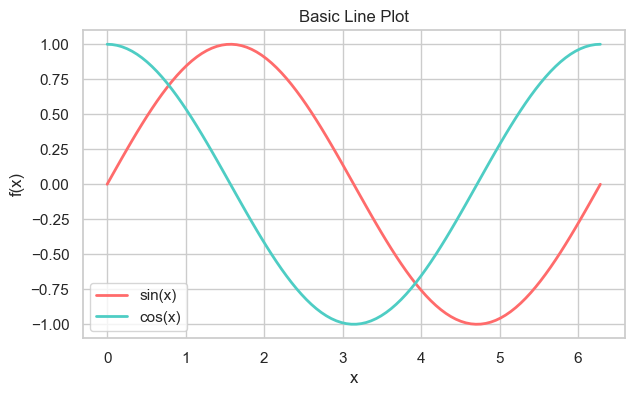

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_sin, label="sin(x)", color="#ff6b6b", linewidth=2)
ax.plot(x, y_cos, label="cos(x)", color="#4ecdc4", linewidth=2)
ax.set_title("Basic Line Plot")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
plt.show()


## 2. Subplots — Comparing Multiple Views at Once

`plt.subplots(rows, cols)` returns a grid of `Axes` objects. This is the standard way to lay out several EDA plots (e.g., one histogram per feature) side by side for quick visual comparison.


In [5]:
# Simulate 3 features with different distributions (as if from a real dataset)
normal_feat = np.random.normal(loc=50, scale=10, size=1000)
skewed_feat = np.random.exponential(scale=20, size=1000)
uniform_feat = np.random.uniform(low=0, high=100, size=1000)


In [6]:
titles = ["Normal Distribution", "Exponential (Skewed) Distribution", "Uniform Distribution"]
data = [normal_feat, skewed_feat, uniform_feat]
colors = ["#4ecdc4", "#ff6b6b", "#ffd93d"]


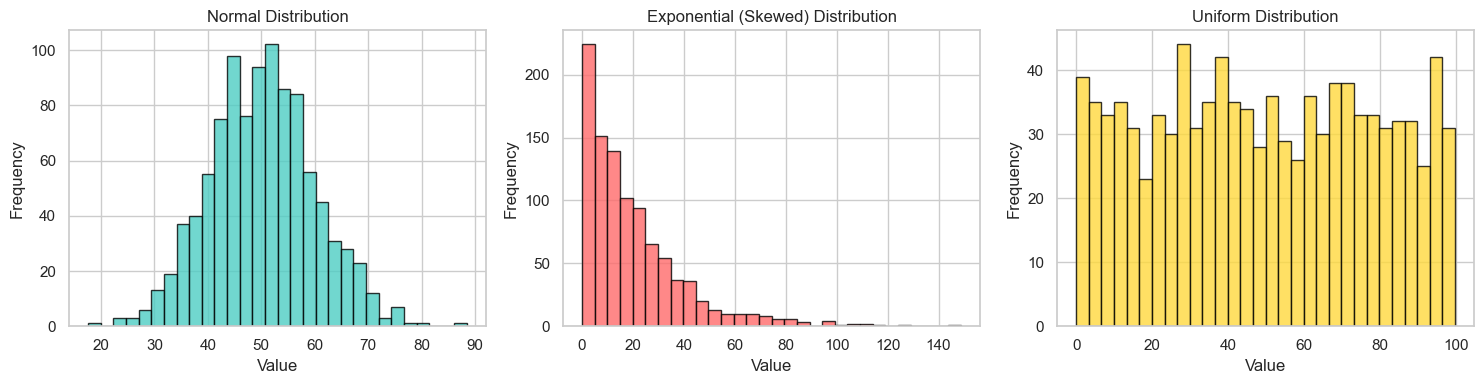

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["Normal Distribution", "Exponential (Skewed) Distribution", "Uniform Distribution"]
data = [normal_feat, skewed_feat, uniform_feat]
colors = ["#4ecdc4", "#ff6b6b", "#ffd93d"]
for a, d, t, c in zip(axes, data, titles, colors):
    a.hist(d, bins=30, color=c, edgecolor="black", alpha=0.8)
    a.set_title(t)
    a.set_xlabel("Value")
    a.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


## 3. Scatter & Bar — Relationships and Categories

- **Scatter plots** reveal relationships between two continuous variables (and, with `hue`, a third categorical one).
- **Bar plots** compare a metric across categories.


In [8]:
# Synthetic dataset: exam study hours vs score, with pass/fail category
study_hours = np.random.uniform(0, 10, 80)
noise = np.random.normal(0, 8, 80)
score = 40 + study_hours * 6 + noise
passed = score >= 60


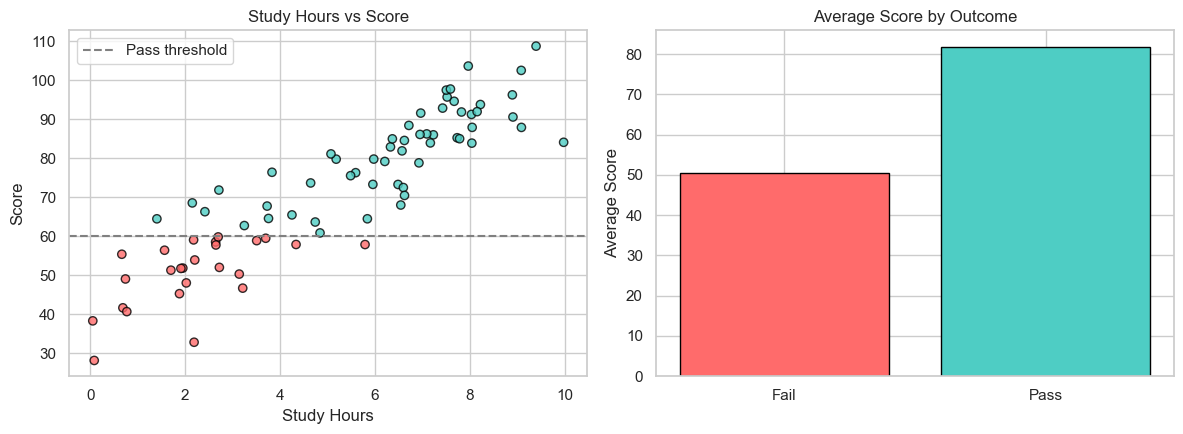

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Scatter: relationship between two continuous variables, colored by category
scatter_colors = np.where(passed, "#4ecdc4", "#ff6b6b")
axes[0].scatter(study_hours, score, c=scatter_colors, edgecolor="black", alpha=0.8)
axes[0].axhline(60, color="gray", linestyle="--", label="Pass threshold")
axes[0].set_title("Study Hours vs Score")
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Score")
axes[0].legend()
# Bar: average score grouped by pass/fail (categorical comparison)
avg_by_group = pd.Series(score).groupby(passed).mean()
axes[1].bar(["Fail", "Pass"], avg_by_group.values, color=["#ff6b6b", "#4ecdc4"], edgecolor="black")
axes[1].set_title("Average Score by Outcome")
axes[1].set_ylabel("Average Score")
plt.tight_layout()
plt.show()


## 4. Seaborn — Statistical Plots Directly on DataFrames

Seaborn functions accept a DataFrame + column names (`data=df, x=..., y=...`), and add statistical layers (density curves, confidence bands, aggregation) that would take many lines of raw Matplotlib to replicate.

Key functions used below:
- `sns.histplot` / `sns.kdeplot` — distribution + smoothed density estimate
- `sns.boxplot` — median, quartiles, and outliers in one view (math in README)
- `sns.heatmap` — matrix visualization, used here for a correlation matrix
- `sns.pairplot` — every pairwise feature relationship in a grid, in one call


In [10]:
# Build a small synthetic "dataset" resembling real tabular ML data
n = 300
df = pd.DataFrame({
    "age": np.random.normal(35, 10, n).clip(18, 70),
    "income": np.random.normal(50000, 15000, n).clip(15000, None),
    "spending_score": np.random.normal(50, 20, n).clip(0, 100),
})
df["income"] += df["age"] * 300   # inject a real correlation: income rises with age
df["segment"] = pd.cut(df["spending_score"], bins=[0, 33, 66, 100], labels=["Low", "Medium", "High"])


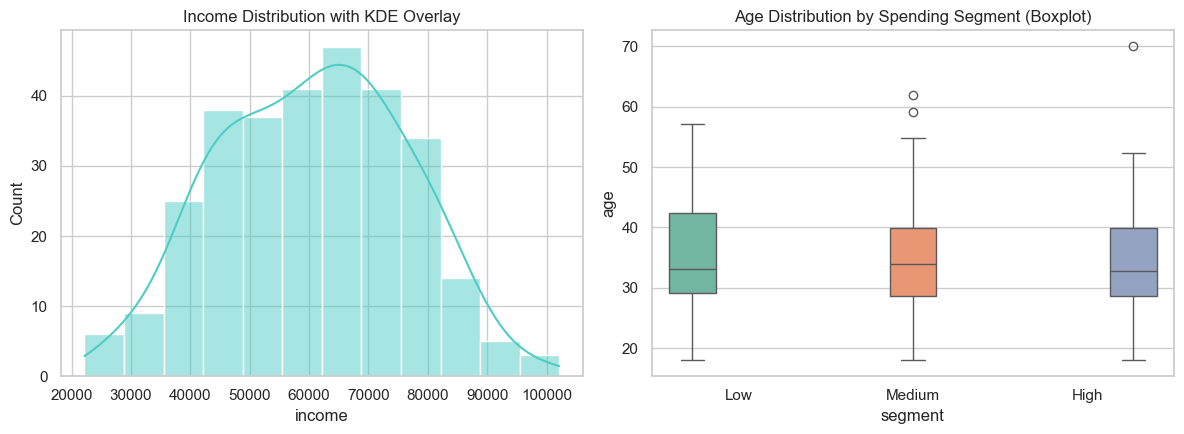

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["income"], kde=True, ax=axes[0], color="#4ecdc4")   # histogram + KDE curve overlay
axes[0].set_title("Income Distribution with KDE Overlay")
sns.boxplot(data=df, x="segment", y="age", hue="segment", legend=False, palette="Set2", ax=axes[1])   # quartiles + outliers per group
axes[1].set_title("Age Distribution by Spending Segment (Boxplot)")
plt.tight_layout()
plt.show()


## 5. Correlation Heatmap — Seeing Relationships at a Glance

A correlation heatmap visualizes the full **correlation matrix** at once — essential before feeding features into any linear model (highly correlated features can destabilize coefficients; see the Ridge/Lasso notebook later in Classical ML).


In [12]:
corr_matrix = df[["age", "income", "spending_score"]].corr()   # Pearson correlation, see README for formula


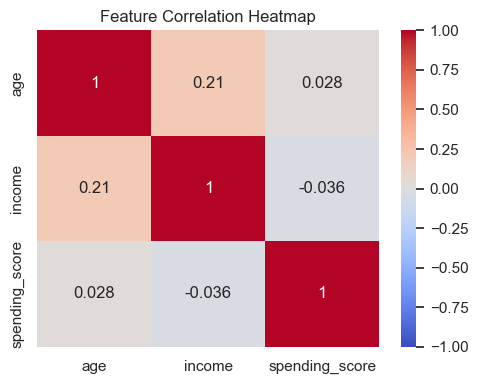

                     age    income  spending_score
age             1.000000  0.209651        0.027659
income          0.209651  1.000000       -0.036293
spending_score  0.027659 -0.036293        1.000000


In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
print(corr_matrix)


## 6. Pairplot — Every Pairwise Relationship, One Call

`sns.pairplot` draws a scatter plot for every feature pair (off-diagonal) and a distribution plot per feature (diagonal) — the fastest way to visually scan a whole small-to-medium feature set for relationships and separability between classes (via `hue`).


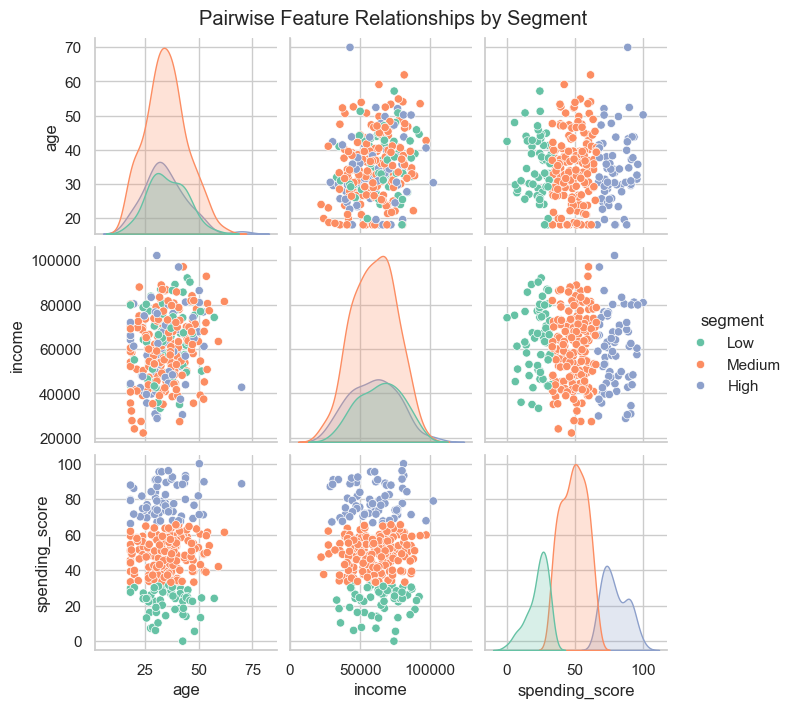

In [14]:
pair_grid = sns.pairplot(df, vars=["age", "income", "spending_score"], hue="segment", palette="Set2", height=2.3)
pair_grid.fig.suptitle("Pairwise Feature Relationships by Segment", y=1.02)
plt.show()


## 7. Outlier Detection via Boxplot (IQR Rule)

The boxplot's whiskers mark the **IQR (Interquartile Range) rule** boundary (formula in README). Points beyond the whiskers are flagged as statistical outliers — a fast visual pre-check before applying any formal outlier-removal step in preprocessing.


In [15]:
# Inject a few deliberate outliers to demonstrate the boxplot's outlier detection
income_with_outliers = pd.concat([df["income"], pd.Series([250000, 260000, -5000])], ignore_index=True)


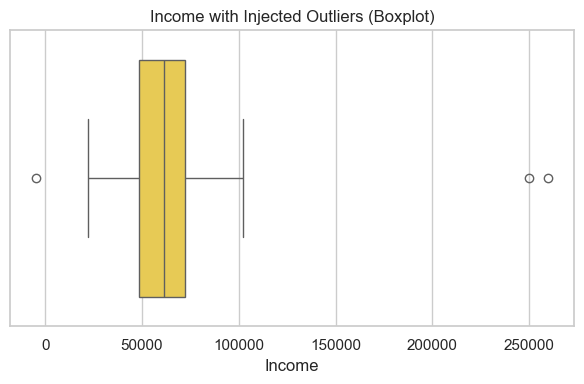

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=income_with_outliers, ax=ax, color="#ffd93d")
ax.set_title("Income with Injected Outliers (Boxplot)")
ax.set_xlabel("Income")
plt.tight_layout()
plt.show()


In [17]:
# Compute the IQR bounds manually to confirm what the boxplot is showing
q1, q3 = income_with_outliers.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = income_with_outliers[(income_with_outliers < lower) | (income_with_outliers > upper)]
print(f"IQR bounds: [{lower:.0f}, {upper:.0f}]")
print("Flagged outliers:", outliers.tolist())


IQR bounds: [12541, 107975]
Flagged outliers: [250000.0, 260000.0, -5000.0]


## 8. Violin Plot — Boxplot + Full Distribution Shape

A violin plot combines a boxplot's summary statistics with a mirrored KDE curve showing the full distribution shape — useful when a boxplot's five-number summary hides multimodal (multiple-peak) structure that a violin plot reveals directly.


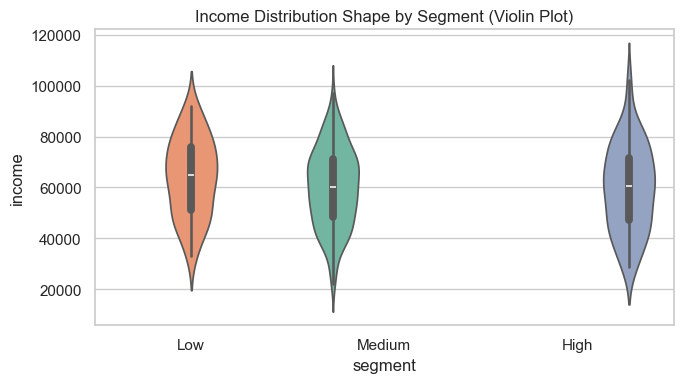

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(data=df, x="segment", y="income", ax=ax, palette="Set2", hue="segment", legend=False)
ax.set_title("Income Distribution Shape by Segment (Violin Plot)")
plt.tight_layout()
plt.show()


## 9. Facet Grid — Small Multiples for Categorical Comparison

`sns.catplot` (built on `FacetGrid`) automatically creates one subplot per category level — the fastest way to compare a distribution across many groups without manually looping over `plt.subplots`.


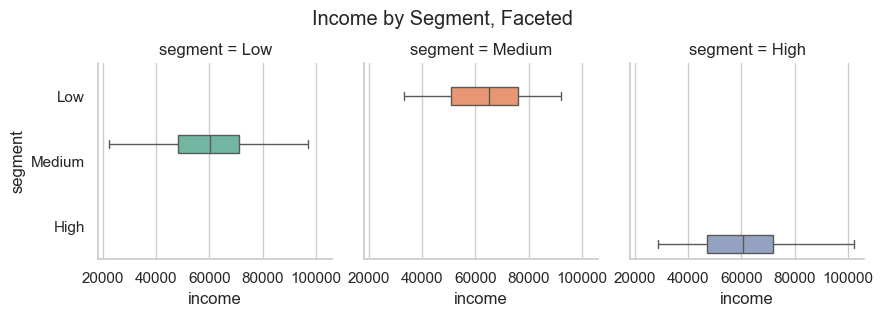

In [19]:
grid = sns.catplot(
    data=df, x="income", y="segment", kind="box",
    col="segment", col_wrap=3, height=3, sharex=True, palette="Set2", hue="segment", legend=False,
)
grid.fig.suptitle("Income by Segment, Faceted", y=1.05)
plt.show()


## 10. Line Plot with Multiple Series, Fill, and Annotation

Combining a shaded confidence band (`fill_between`) with direct annotation (`ax.annotate`) turns a plain line chart into a self-explanatory figure — a skill worth having beyond the default Seaborn styling.


In [20]:
x = np.linspace(0, 10, 50)
y_mean = np.sin(x) * 5 + 20
y_upper = y_mean + np.random.uniform(1, 3, size=50)
y_lower = y_mean - np.random.uniform(1, 3, size=50)


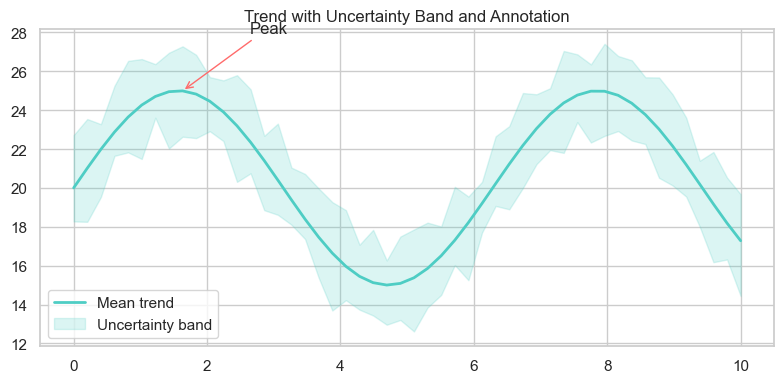

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y_mean, color="#4ecdc4", linewidth=2, label="Mean trend")
ax.fill_between(x, y_lower, y_upper, color="#4ecdc4", alpha=0.2, label="Uncertainty band")
peak_idx = np.argmax(y_mean)
ax.annotate("Peak", xy=(x[peak_idx], y_mean[peak_idx]),
            xytext=(x[peak_idx] + 1, y_mean[peak_idx] + 3),
            arrowprops=dict(arrowstyle="->", color="#ff6b6b"))
ax.set_title("Trend with Uncertainty Band and Annotation")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Stacked Bar Chart — Part-to-Whole Comparison Across Categories

A stacked bar chart shows both the total and the composition of each category at once — useful for comparing, e.g., segment composition across regions.


In [22]:
composition = pd.DataFrame({
    "Low": [30, 45, 20],
    "Medium": [40, 35, 50],
    "High": [30, 20, 30],
}, index=["Region A", "Region B", "Region C"])


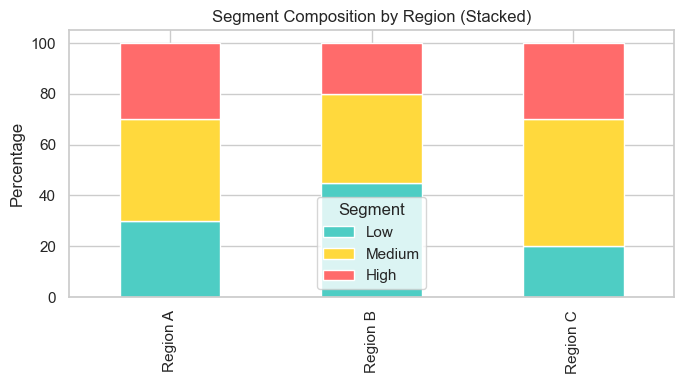

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
composition.plot(kind="bar", stacked=True, ax=ax, color=["#4ecdc4", "#ffd93d", "#ff6b6b"])
ax.set_title("Segment Composition by Region (Stacked)")
ax.set_ylabel("Percentage")
ax.legend(title="Segment")
plt.tight_layout()
plt.show()


## 12. Joint Plot — Scatter + Marginal Distributions + Regression Line

`sns.jointplot` combines a scatter/regression plot with each variable's marginal distribution on the axes — a compact way to check both the relationship *and* each variable's individual shape in one figure.


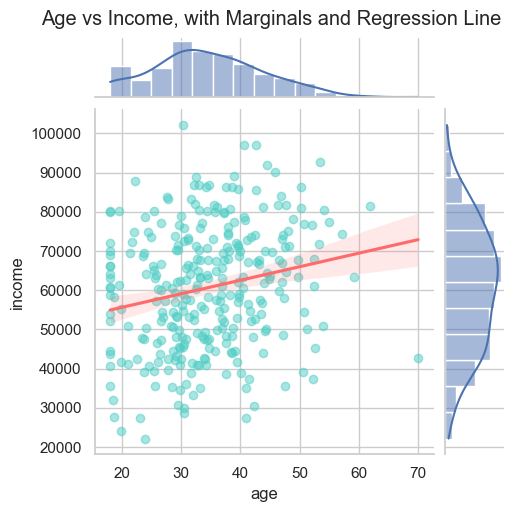

In [24]:
joint = sns.jointplot(data=df, x="age", y="income", kind="reg", height=5,
                       scatter_kws={"alpha": 0.5, "color": "#4ecdc4"}, line_kws={"color": "#ff6b6b"})
joint.fig.suptitle("Age vs Income, with Marginals and Regression Line", y=1.02)
plt.show()


## 13. Log-Scale Axes — Visualizing Skewed Data Honestly

A linear axis compresses a right-skewed distribution's small values into an unreadable cluster near zero. Switching to a **log scale** spreads them out evenly — essential for data spanning multiple orders of magnitude (income, population, viral growth).


In [25]:
skewed_data = np.random.lognormal(mean=3, sigma=1.2, size=1000)


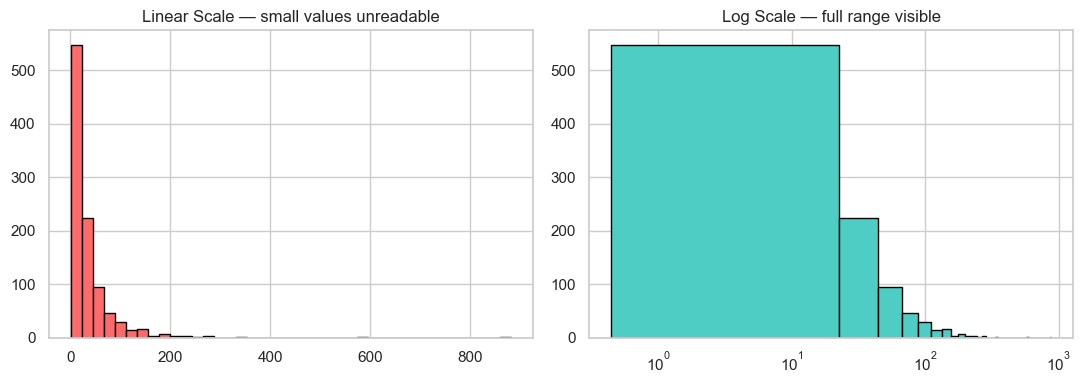

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(skewed_data, bins=40, color="#ff6b6b", edgecolor="black")
axes[0].set_title("Linear Scale — small values unreadable")
axes[1].hist(skewed_data, bins=40, color="#4ecdc4", edgecolor="black")
axes[1].set_xscale("log")
axes[1].set_title("Log Scale — full range visible")
plt.tight_layout()
plt.show()


## 14. Saving Figures to File

`fig.savefig()` exports a plot at publication quality. `dpi=` controls resolution, `bbox_inches="tight"` trims excess whitespace — both matter when a figure is going into a report or README rather than just being viewed inline.


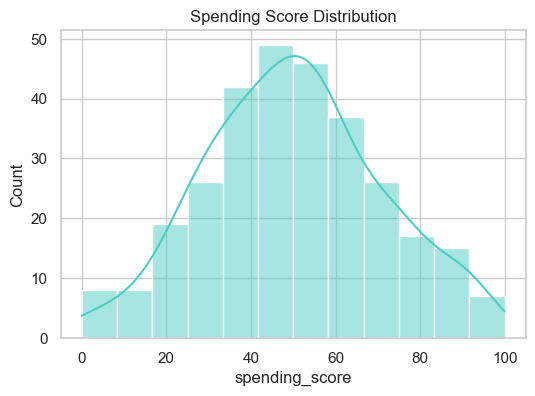

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df["spending_score"], kde=True, ax=ax, color="#4ecdc4")
ax.set_title("Spending Score Distribution")
fig.savefig("spending_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [28]:
import os
print("Saved file exists:", os.path.exists("spending_score_distribution.png"))
print("File size (KB):", round(os.path.getsize("spending_score_distribution.png") / 1024, 1))


Saved file exists: True
File size (KB): 38.5


## 15. Error Bar Plot — Visualizing Uncertainty on Point Estimates

Error bars show a point estimate (e.g. a group mean) alongside its uncertainty (e.g. standard error or standard deviation) — critical whenever comparing group averages, so a viewer can judge whether an apparent difference is likely real or just noise.


In [29]:
group_stats = df.groupby("segment", observed=True)["spending_score"].agg(["mean", "std"])


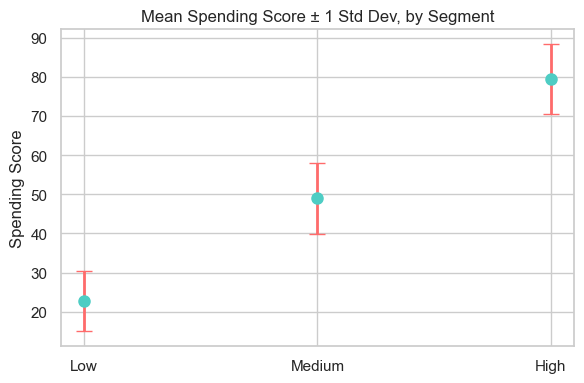

              mean       std
segment                     
Low      22.628511  7.678531
Medium   48.933340  9.073685
High     79.439062  9.005363


In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(group_stats.index, group_stats["mean"], yerr=group_stats["std"],
            fmt="o", capsize=6, color="#4ecdc4", ecolor="#ff6b6b", markersize=8, linewidth=2)
ax.set_title("Mean Spending Score ± 1 Std Dev, by Segment")
ax.set_ylabel("Spending Score")
plt.tight_layout()
plt.show()
print(group_stats)


## ✅ Key Takeaways

- Always create `Figure`/`Axes` explicitly (`fig, ax = plt.subplots()`) — it scales cleanly to multi-plot EDA grids.
- Histograms + KDE reveal a feature's **shape** (skew, modality); boxplots reveal its **spread and outliers** via the IQR rule.
- A correlation heatmap is the fastest sanity check before any linear model — watch for near-1.0 correlations between features.
- `sns.pairplot` is usually the single most useful command for first-look EDA on a small tabular dataset.
- Violin plots reveal multimodal shape a boxplot's five-number summary can hide; `sns.catplot`/`FacetGrid` beats manually looping `plt.subplots` for many-category comparisons.
- Log-scale axes are not optional for right-skewed data spanning orders of magnitude — a linear axis will visually lie about where most of the data actually sits.
- Every plot in this notebook will reappear as a diagnostic tool in later notebooks — e.g., boxplots for outlier prep, heatmaps before Ridge/Lasso, scatter plots for regression residuals.

**Next up:** [03_Data_Preprocessing_EDA](../03_Data_Preprocessing_EDA/) — turning these visual insights into cleaning/transformation code.
